In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[]


In [2]:
import zipfile
import os

zip_path = "/content/Student_Projects.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

os.listdir(extract_path)


['CELOSIA ARGENTEA L', 'PURPLE CHLORIS', 'CROWFOOT GRASS']

In [3]:
!pip install tensorflow


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    "/content/dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "/content/dataset",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 155 images belonging to 3 classes.
Found 38 images belonging to 3 classes.


In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.3978 - loss: 1.3945 - val_accuracy: 0.4474 - val_loss: 1.1683
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4322 - loss: 1.1522 - val_accuracy: 0.6316 - val_loss: 1.0124
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5031 - loss: 1.1444 - val_accuracy: 0.6316 - val_loss: 0.9297
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5622 - loss: 1.0162 - val_accuracy: 0.7105 - val_loss: 0.8160
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5686 - loss: 0.9492 - val_accuracy: 0.6842 - val_loss: 0.7441
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7270 - loss: 0.7122 - val_accuracy: 0.8158 - val_loss: 0.7091
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7342 - loss: 0.6774 - val_accuracy: 0.8421 - val_loss: 0.5943
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7530 - loss: 0.6679 - val_accuracy: 0.8158 - val_loss: 0.6544
Epoch 9/2

In [7]:
base_model.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 81s 10s/step - accuracy: 0.4746 - loss: 1.0981 - val_accuracy: 0.9737 - val_loss: 0.2471
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 7s/step - accuracy: 0.6001 - loss: 0.9191 - val_accuracy: 0.9737 - val_loss: 0.2491
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 7s/step - accuracy: 0.7107 - loss: 0.6675 - val_accuracy: 0.9474 - val_loss: 0.2765
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 36s 7s/step - accuracy: 0.7000 - loss: 0.7135 - val_accuracy: 0.9211 - val_loss: 0.2906
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 7s/step - accuracy: 0.6889 - loss: 0.7862 - val_accuracy: 0.8947 - val_loss: 0.3161
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 7s/step - accuracy: 0.7176 - loss: 0.7001 - val_accuracy: 0.8158 - val_loss: 0.3291
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 35s 7s/step - accuracy: 0.7617 - loss: 0.6542 - val_accuracy: 0.9474 - val_loss: 0.2620
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 7s/step - accuracy: 0.7310 - loss: 0.5848 - val_accuracy: 0.9474 - val_loss: 0.3074
Epoch 9

In [8]:
loss, accuracy = model.evaluate(val_data)
print(f"Final Validation Accuracy: {accuracy * 100:.2f}%")


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.9161 - loss: 0.3385
Final Validation Accuracy: 92.11%


In [9]:
model.save("/content/plant_classification_model.h5")


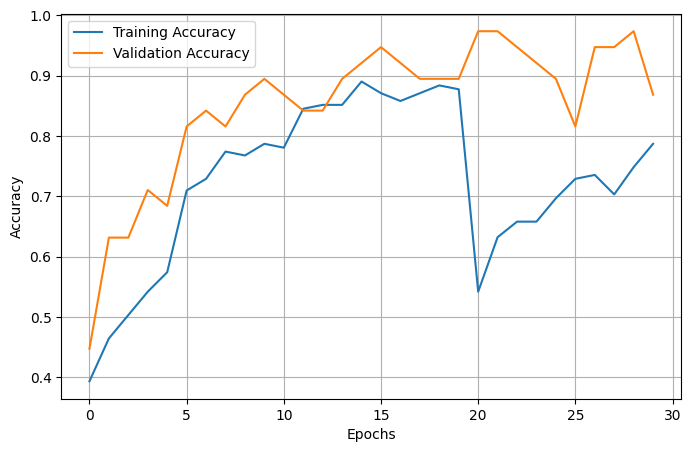

In [ ]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

if 'history_fine' in globals():
    acc += history_fine.history['accuracy']
    val_acc += history_fine.history['val_accuracy']

epochs = range(len(acc))

plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import cv2
from tensorflow.keras.preprocessing import image
import os
dataset_root = "/content/dataset"


class_dirs = [d for d in os.listdir(dataset_root) if os.path.isdir(os.path.join(dataset_root, d))]

img_path = None
if class_dirs:
    first_class_dir = os.path.join(dataset_root, class_dirs[0])
    image_files = [f for f in os.listdir(first_class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if image_files:
        img_path = os.path.join(first_class_dir, image_files[0])
        print(f"Using image: {img_path} for testing.")
    else:
        print(f"No image files found in the directory: {first_class_dir}")
else:
    print(f"No class directories found in the dataset root: {dataset_root}")

if img_path:
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    print("Image loaded successfully.")
else:
    print("Could not load any image for testing. Please ensure your dataset contains images.")

Using image: /content/dataset/CELOSIA ARGENTEA L/23988564-b739-4e67-87ad-38d9394847c3.jpeg for testing.
Image loaded successfully.


In [14]:
pred = model.predict(img_array)
class_index = np.argmax(pred)
confidence = np.max(pred) * 100

class_names = list(train_data.class_indices.keys())
predicted_class = class_names[class_index]


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


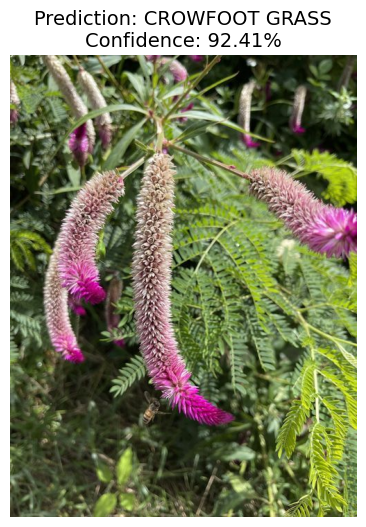

In [ ]:
display_img = cv2.imread(img_path)
display_img = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(display_img)
plt.axis('off')

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%",
    fontsize=14
)

plt.show()
